In [2]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import torch
from gencase import *
from util import visualize, sampleParticles, generateInitialVariables, SamplingScheme
from sample import smoothState, addNoise, populateCGrid, populateUGrid, smoothValues
from util import plotState, plotInitialState
from simulation import runSimulation
from util import getCurrentTimestamp
from argparse import ArgumentParser

import h5py

In [3]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

In [4]:
simFolder = 'output/waveEqn_128_regular_2026-02-06_09-20-54/'
files = os.listdir(simFolder)
files = [f for f in files if f.endswith('.h5')]
files.sort()
print(files)


['simulationData.h5']


In [5]:
fileIndex = 0
fileName = os.path.join(simFolder, files[fileIndex])
print(f"Loading from {fileName}")
loadedFile = h5py.File(fileName, 'r')


Loading from output/waveEqn_128_regular_2026-02-06_09-20-54/simulationData.h5


In [6]:

print("Keys in the loaded HDF5 file:")
for key in loadedFile.keys():
    print(key)

print("\nAttributes in the loaded HDF5 file:")
for attr in loadedFile.attrs.keys():
    print(f'{attr}: {loadedFile.attrs[attr]}')

for key in loadedFile.keys():
    data = loadedFile[key]
    print(f'\nData for key "{key}":')
    if isinstance(data, h5py.Dataset):
        print(f'Shape: {data.shape}, Dtype: {data.dtype}')
        # print(data[:])  # Print the actual data
    else:
        if isinstance(data, h5py.Group):
            print(f'Group with attributes:')
            for attr in data.attrs.keys():
                print(f'  {attr}: {data.attrs[attr]}')
            print(f'Group with keys: {list(data.keys())}')
            for subkey in data.keys():
                subdata = data[subkey]
                print(f'  Data for subkey "{subkey}":')
                if isinstance(subdata, h5py.Dataset):
                    print(f'    Shape: {subdata.shape}, Dtype: {subdata.dtype}')
                    # print(subdata[:])  # Print the actual data
                else:
                    for attr in subdata.attrs.keys():
                        print(f'    {attr}: {subdata.attrs[attr]}')
                    if isinstance(subdata, h5py.Group):
                        print(f'    Group with keys: {list(subdata.keys())}')
                        for subsubkey in subdata.keys():
                            subsubdata = subdata[subsubkey]
                            print(f'      Data for subsubkey "{subsubkey}":')
                            if isinstance(subsubdata, h5py.Dataset):
                                print(f'        Shape: {subsubdata.shape}, Dtype: {subsubdata.dtype}')
                                
                # break
    print(data)

Keys in the loaded HDF5 file:
initialWaveState
particles
simulation

Attributes in the loaded HDF5 file:

Data for key "initialWaveState":
Group with attributes:
Group with keys: ['c', 'damping', 'u', 'v']
  Data for subkey "c":
    Shape: (16384,), Dtype: float32
  Data for subkey "damping":
    Shape: (16384,), Dtype: float32
  Data for subkey "u":
    Shape: (16384,), Dtype: float32
  Data for subkey "v":
    Shape: (16384,), Dtype: float32
<HDF5 group "/initialWaveState" (4 members)>

Data for key "particles":
Group with attributes:
Group with keys: ['densities', 'masses', 'numNeighbors', 'positions', 'supports']
  Data for subkey "densities":
    Shape: (16384,), Dtype: float32
  Data for subkey "masses":
    Shape: (16384,), Dtype: float32
  Data for subkey "numNeighbors":
    Shape: (16384,), Dtype: int64
  Data for subkey "positions":
    Shape: (16384, 2), Dtype: float32
  Data for subkey "supports":
    Shape: (16384,), Dtype: float32
<HDF5 group "/particles" (5 members)>

Da

In [37]:
import math
numParticles = loadedFile['particles']['positions'][:].shape[0]
nx = int(math.sqrt(numParticles))
dt = loadedFile['simulation'].attrs['dt']

print(f'Number of particles: {numParticles}, inferred nx: {nx}')


config, domain, device, dtype, kernel = generateInitialVariables(
    nx, device = device
)

schemeToLoad = loadedFile['simulation'].attrs['integrationScheme']
config['integrationScheme'] = None
for scheme in IntegrationSchemeType:
    # print(f'Checking scheme: {scheme.value} against loaded scheme: {schemeToLoad}')
    if scheme.name == schemeToLoad:
        config['integrationScheme'] = scheme
        print(f'Inferred integration scheme: {config["integrationScheme"]}')
        break

integrator = getIntegrator(config['integrationScheme'])


Number of particles: 16384, inferred nx: 128


0it [00:00, ?it/s]

Inferred integration scheme: IntegrationSchemeType.rungeKutta4


In [38]:
positions = torch.tensor(loadedFile['particles']['positions'][:], device = device, dtype = torch.float32)
supports = torch.tensor(loadedFile['particles']['supports'][:], device = device, dtype = torch.float32)
masses = torch.tensor(loadedFile['particles']['masses'][:], device = device, dtype = torch.float32)
densities = torch.tensor(loadedFile['particles']['densities'][:], device = device, dtype = torch.float32)

particleState = BasicState(positions, supports, masses, densities, torch.zeros_like(positions), torch.zeros(positions.shape[0], device = device, dtype = torch.int64), torch.zeros(positions.shape[0], device = device, dtype = torch.int64), torch.arange(positions.shape[0], device = device), positions.shape[0])
neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
particleState.numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries
particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)

In [39]:
timestep = 0
numTimesteps = loadedFile['simulation']['u'].shape[0]
print(f'Loaded simulation data with {numTimesteps} timesteps, each with shape {loadedFile["simulation"]["u"].shape[1:]}')

uGrid = torch.tensor(loadedFile['simulation']['u'][timestep], dtype = torch.float32, device = device)
vGrid = torch.tensor(loadedFile['simulation']['v'][timestep], dtype = torch.float32, device = device)
cGrid = torch.tensor(loadedFile['simulation']['c'][timestep], dtype = torch.float32, device = device)
dampGrid = torch.tensor(loadedFile['simulation']['damping'][timestep], dtype = torch.float32, device = device)
# print(f'Loaded uGrid with shape {uGrid.shape} and dtype {uGrid.dtype}')


waveState = WaveEquationState(
    u = uGrid,
    v = vGrid,
    c = cGrid,
    damping = dampGrid,
)
# smoothedState = smoothState(waveState, particleState, 0, neighbors, config)

waveSystem = WaveSystem(
    systemState = particleState,
    waveState = waveState,
    neighborhood = neighbors.get('noghost'),
    t = timestep * dt
)

Loaded simulation data with 1025 timesteps, each with shape (16384, 1)


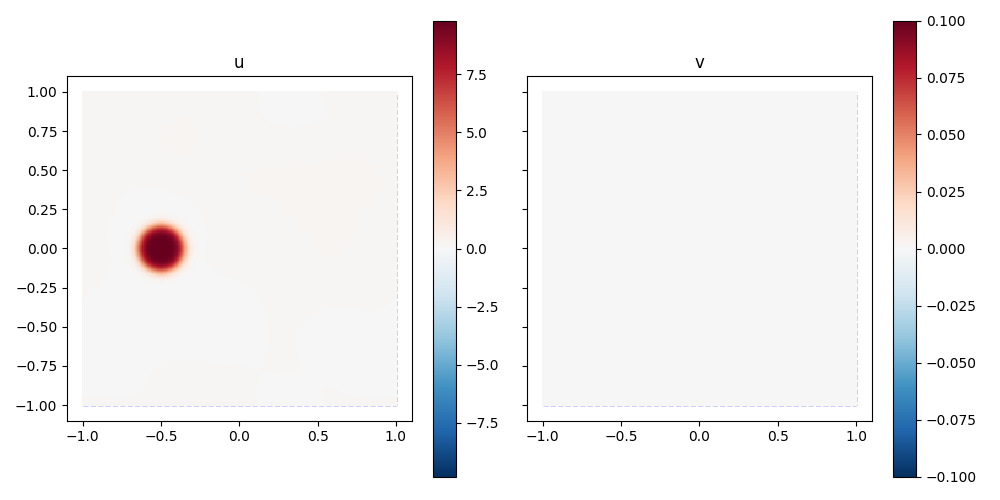

In [40]:

fig, axis, uPlot, vPlot, cPlot, dampPlot = plotState(
    particleState,
    waveState,
    config, kernel,
    markerSize = 0.5,
    plotGrid = True,
    plotCD = False)
# fig.savefig(f'output/{folderName}/initial_state.png', dpi = args.figureDpi)

In [42]:
for i in range(32):
    waveSystem, updates =  integrator.function(
        waveSystem,
        dt = dt,
        f = waveSystemFunction,
        verbose = False,
        config = config,
    )
    updatePlot(uPlot, particleState, waveSystem.waveState.u)
    updatePlot(vPlot, particleState, waveSystem.waveState.v)
    fig.canvas.draw()
    fig.canvas.flush_events()